<a href="https://colab.research.google.com/github/Muqqadas30/fsdl-my-labs/blob/main/lab01/lab01_mlp_raw_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

Train samples: 60000
Test samples: 10000


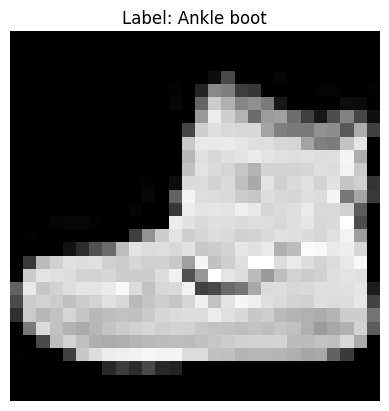

In [4]:
image, label = train_dataset[0]
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {class_names[label]}")
plt.axis("off")
plt.show()

In [5]:
class SimpleMLP(nn.Module):
    def __init__(self, input_size=784, hidden1=256, hidden2=128, num_classes=10):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_size, hidden1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden2, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

model = SimpleMLP().to(device)
print(model)

SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [7]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total


def train(model, train_loader, test_loader, criterion, optimizer, epochs=5):
    history = {"train_loss": [], "test_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        test_acc = evaluate(model, test_loader)

        history["train_loss"].append(avg_loss)
        history["test_acc"].append(test_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_loss:.4f} | Test Accuracy: {test_acc:.4f}")

    return history

history = train(model, train_loader, test_loader, criterion, optimizer, epochs=5)

Epoch 1/5 | Train Loss: 0.4959 | Test Accuracy: 0.8427
Epoch 2/5 | Train Loss: 0.3677 | Test Accuracy: 0.8589
Epoch 3/5 | Train Loss: 0.3287 | Test Accuracy: 0.8661
Epoch 4/5 | Train Loss: 0.3024 | Test Accuracy: 0.8754
Epoch 5/5 | Train Loss: 0.2853 | Test Accuracy: 0.8712


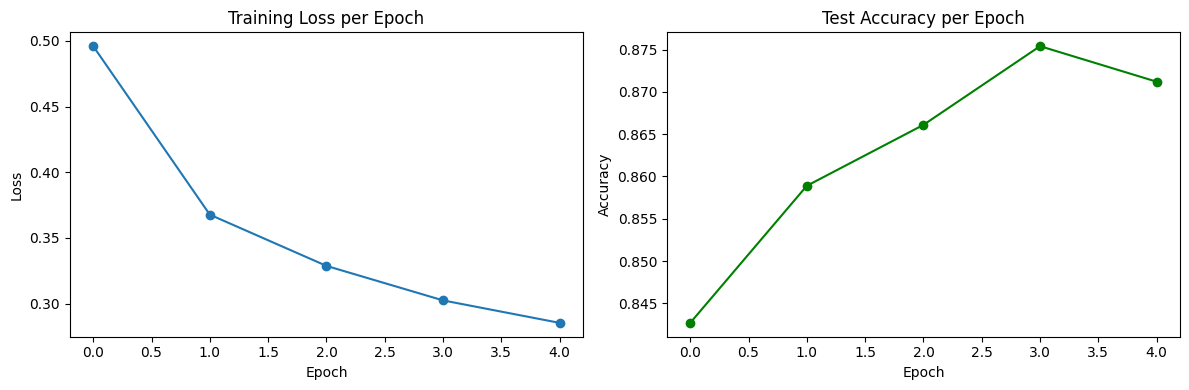

Final Test Accuracy: 87.12%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], marker="o")
axes[0].set_title("Training Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(history["test_acc"], marker="o", color="green")
axes[1].set_title("Test Accuracy per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()

print(f"Final Test Accuracy: {history['test_acc'][-1]:.2%}")

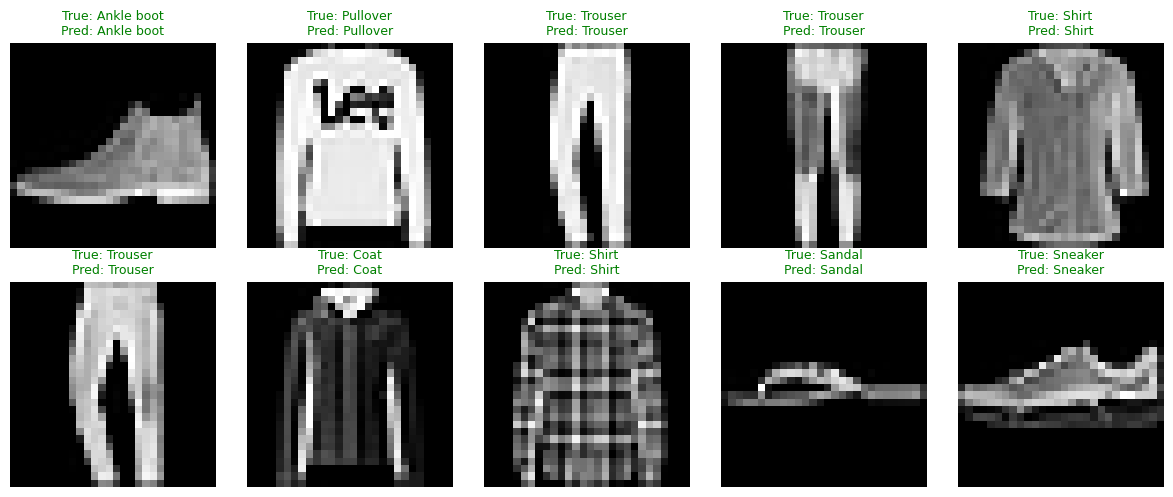

In [9]:
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img = images[i].cpu().squeeze()
    true_label = class_names[labels[i].item()]
    pred_label = class_names[preds[i].item()]
    color = "green" if true_label == pred_label else "red"

    ax.imshow(img, cmap="gray")
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()